In [5]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

In [20]:
from sklearn.datasets import load_diabetes

diab_data = load_diabetes()
X = diab_data.data
y = diab_data.target
features = diab_data.feature_names

print(f"Shape of Feature Matrix :{X.shape}")
print(f"Training data sets: {X.shape[0]} | Total Features: {X.shape[1]}")
print("Feature Names :",features)
print(f"Shape of Target Vector :{y.shape}") 

Shape of Feature Matrix :(442, 10)
Training data sets: 442 | Total Features: 10
Feature Names : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Shape of Target Vector :(442,)


(442, 11)


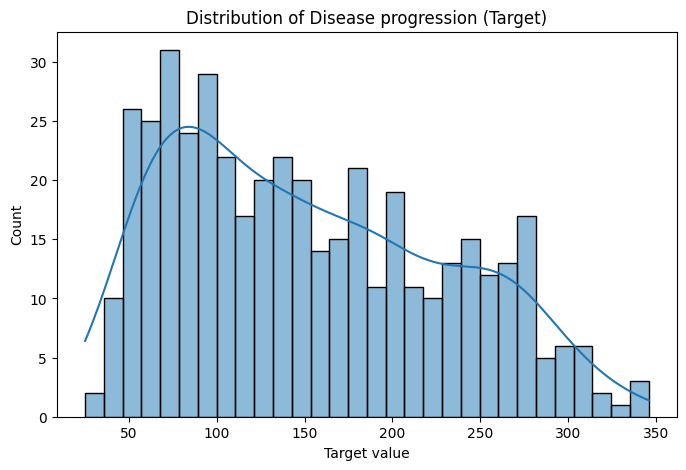

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

#crating the dataFrame
df = pd.DataFrame(X,columns=features)
df['target']  = y 

#print(df.head())
print(df.shape)


plt.figure(figsize=(8,5))
sns.histplot(df['target'], bins = 30, kde=True)
plt.title('Distribution of Disease progression (Target)')
plt.xlabel('Target value')
plt.show()
   

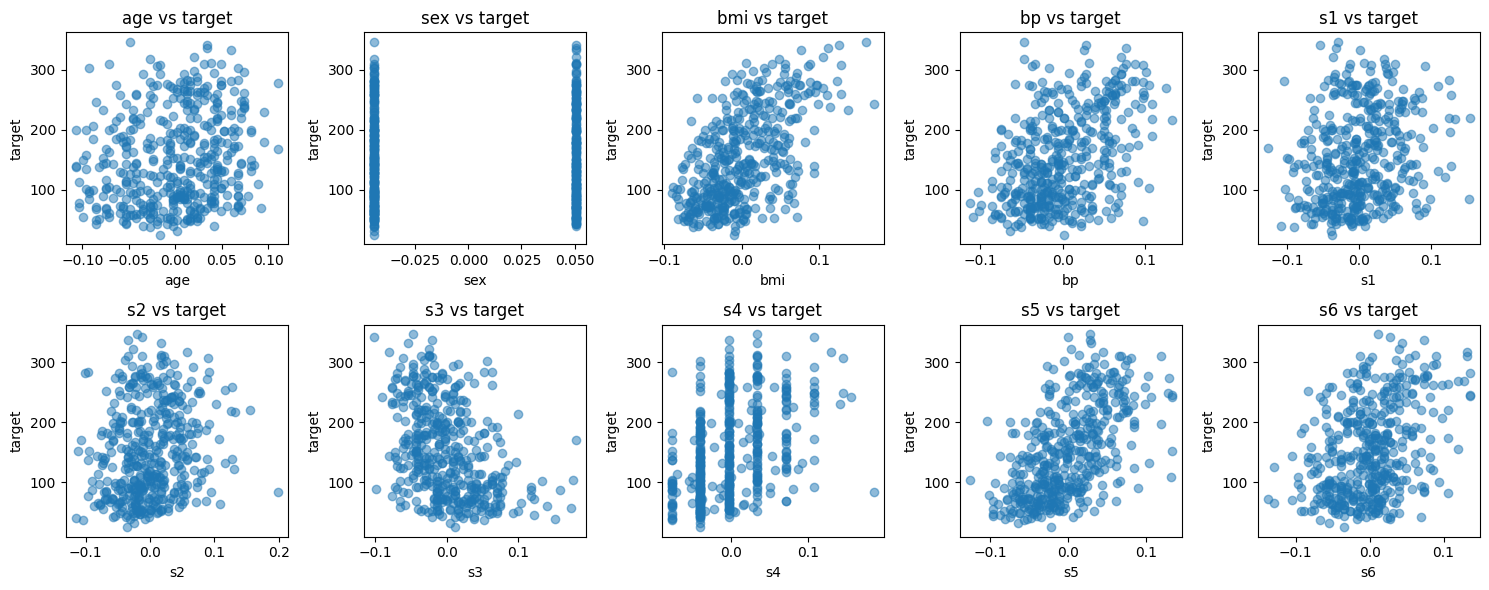

In [25]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, col in enumerate(diab_data.feature_names):
    axes[i].scatter(df[col], df['target'], alpha=0.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('target')
    axes[i].set_title(f'{col} vs target')

plt.tight_layout()
plt.show()

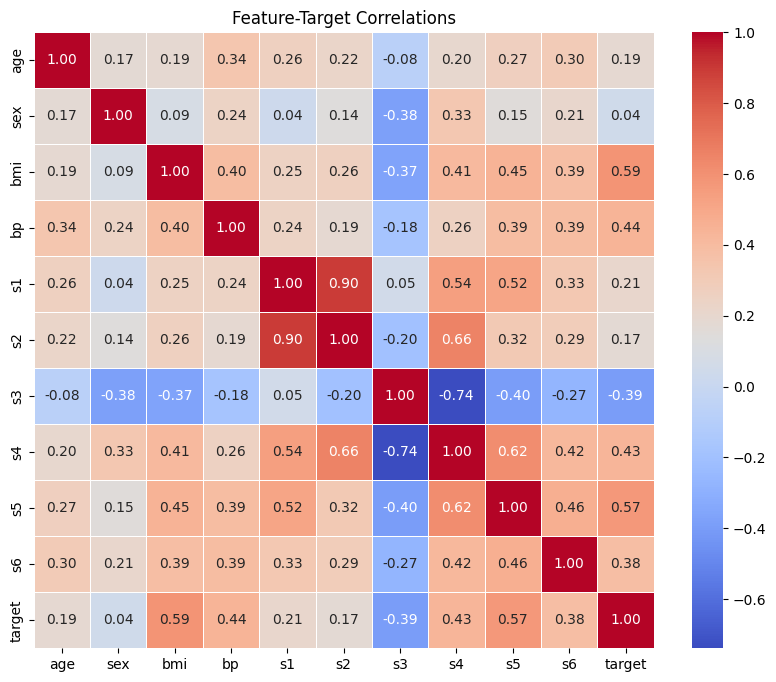

In [26]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature-Target Correlations')
plt.show()

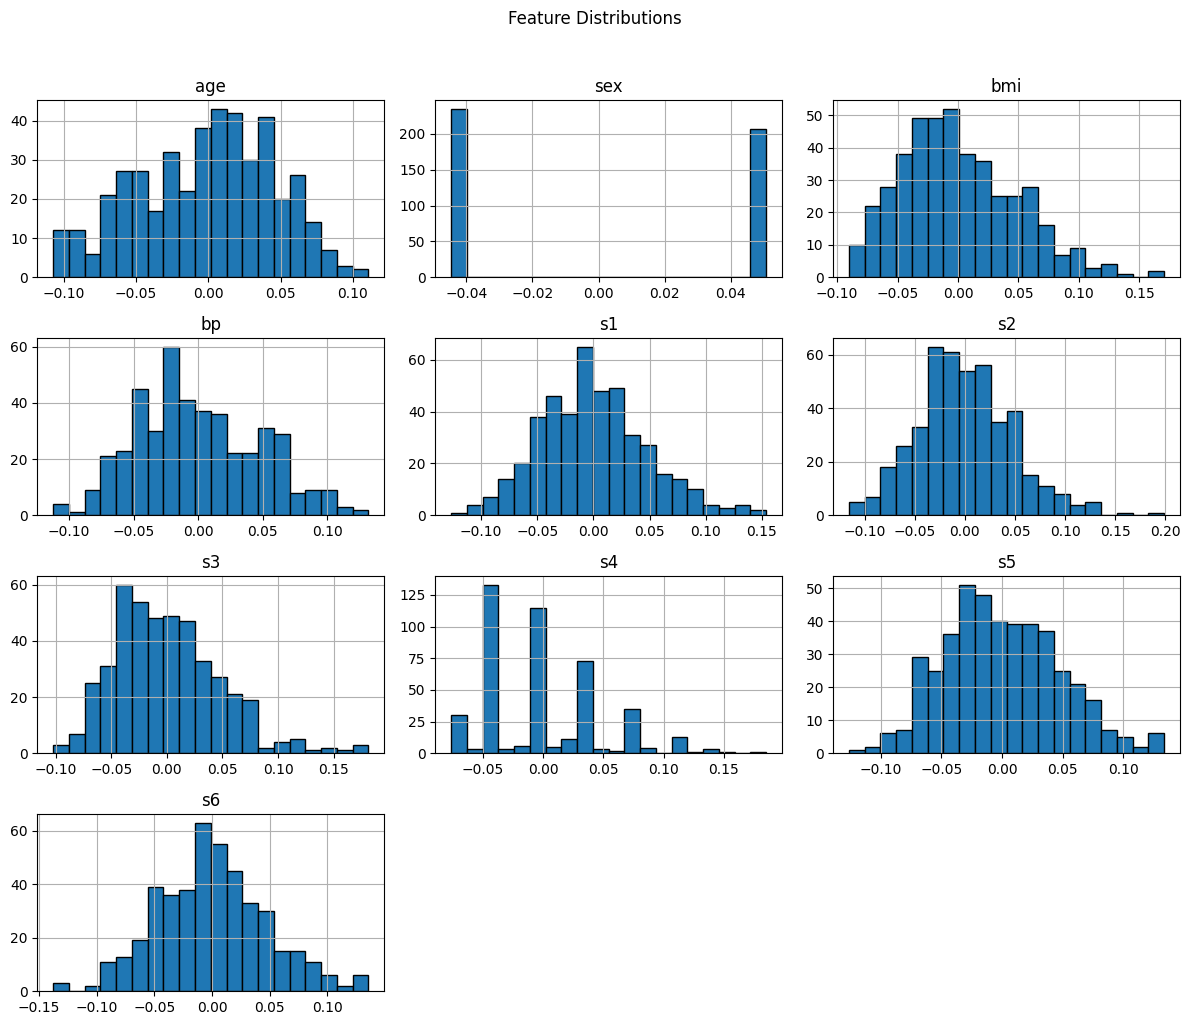

In [27]:
df.iloc[:, :-1].hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Add intercept term (column of ones)
X_b = np.c_[np.ones((X.shape[0], 1)), X]   # shape (442, 11)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print("Best parameters (including intercept):", theta_best)

Best parameters (including intercept): [ 152.13348416  -10.0098663  -239.81564367  519.84592005  324.3846455
 -792.17563855  476.73902101  101.04326794  177.06323767  751.27369956
   67.62669218]


In [29]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True)  # already adds intercept
model.fit(X, y)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 152.13348416289597
Coefficients: [ -10.0098663  -239.81564367  519.84592005  324.3846455  -792.17563855
  476.73902101  101.04326794  177.06323767  751.27369956   67.62669218]


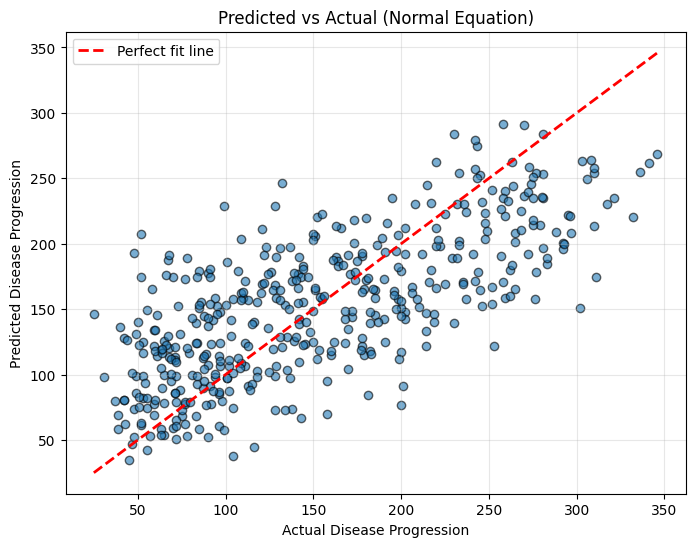

R² Score: 0.5177


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score

# Load data
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Add intercept term and compute normal equation
X_b = np.c_[np.ones((X.shape[0], 1)), X]
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

# Predict on the training set
y_pred = X_b @ theta_best

# Plot predicted vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect fit line')
plt.xlabel('Actual Disease Progression')
plt.ylabel('Predicted Disease Progression')
plt.title('Predicted vs Actual (Normal Equation)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Calculate R² score
r2 = r2_score(y, y_pred)
print(f"R² Score: {r2:.4f}")

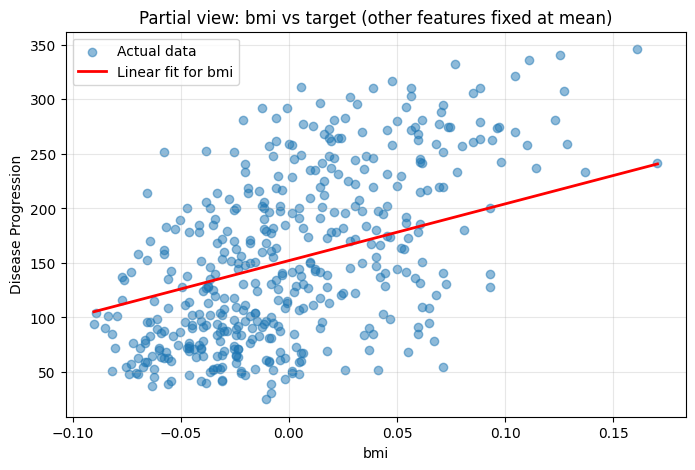

In [31]:
# Choose a feature, e.g., BMI (index 2)
feature_idx = 2  # 'bmi'
feature_name = diabetes.feature_names[feature_idx]

# Create a grid of values for this feature (from min to max)
x_grid = np.linspace(X[:, feature_idx].min(), X[:, feature_idx].max(), 100)

# Fix all other features at their mean (which is 0 for this standardised dataset)
X_other_mean = np.zeros_like(X[0])
X_other_mean[feature_idx] = 1.0  # placeholder, we'll replace
# Actually, easier: make a matrix where all features are 0 (mean) except the chosen one
X_temp = np.zeros((100, X.shape[1]))
X_temp[:, feature_idx] = x_grid
X_temp_b = np.c_[np.ones((100, 1)), X_temp]

# Predict using the fitted parameters
y_pred_grid = X_temp_b @ theta_best

# Scatter actual data for this feature vs target
plt.figure(figsize=(8,5))
plt.scatter(X[:, feature_idx], y, alpha=0.5, label='Actual data')
plt.plot(x_grid, y_pred_grid, 'r-', lw=2, label=f'Linear fit for {feature_name}')
plt.xlabel(feature_name)
plt.ylabel('Disease Progression')
plt.title(f'Partial view: {feature_name} vs target (other features fixed at mean)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

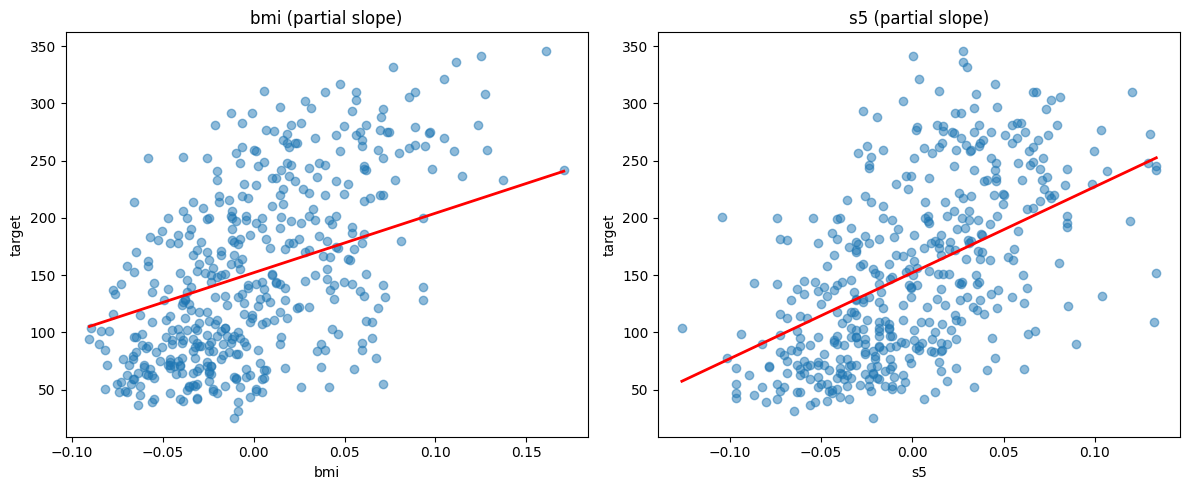

In [32]:
import pandas as pd

# Correlation to pick top 2 features
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y
corr_with_target = df.corr()['target'].abs().sort_values(ascending=False)
top_features = corr_with_target.index[1:3]  # skip target itself

fig, axes = plt.subplots(1, len(top_features), figsize=(12, 5))

for idx, feat in enumerate(top_features):
    col_idx = diabetes.feature_names.index(feat)
    x_col = X[:, col_idx]
    # Partial predictions for this feature
    x_grid = np.linspace(x_col.min(), x_col.max(), 100)
    X_temp = np.zeros((100, X.shape[1]))
    X_temp[:, col_idx] = x_grid
    X_temp_b = np.c_[np.ones((100,1)), X_temp]
    y_partial = X_temp_b @ theta_best
    
    axes[idx].scatter(x_col, y, alpha=0.5)
    axes[idx].plot(x_grid, y_partial, 'r-', lw=2)
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('target')
    axes[idx].set_title(f'{feat} (partial slope)')

plt.tight_layout()
plt.show()